--- Starting Training (Rank=16, Epochs=5) ---


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


Epoch 1/5 | Loss: 1.5596 | Train Acc: 41.60%
Epoch 2/5 | Loss: 1.0283 | Train Acc: 63.78%
Epoch 3/5 | Loss: 0.7568 | Train Acc: 73.89%
Epoch 4/5 | Loss: 0.5900 | Train Acc: 79.96%
Epoch 5/5 | Loss: 0.4781 | Train Acc: 83.85%

--- Evaluating Semantic Coherence ---

=== RESULTS FOR REBUTTAL ===
Cat-Dog Coherence (P_3,5): 0.0478
Cat-Car Coherence (P_3,1): 0.0037

Heatmap successfully saved to: /content/semantic_coherence_heatmap.png


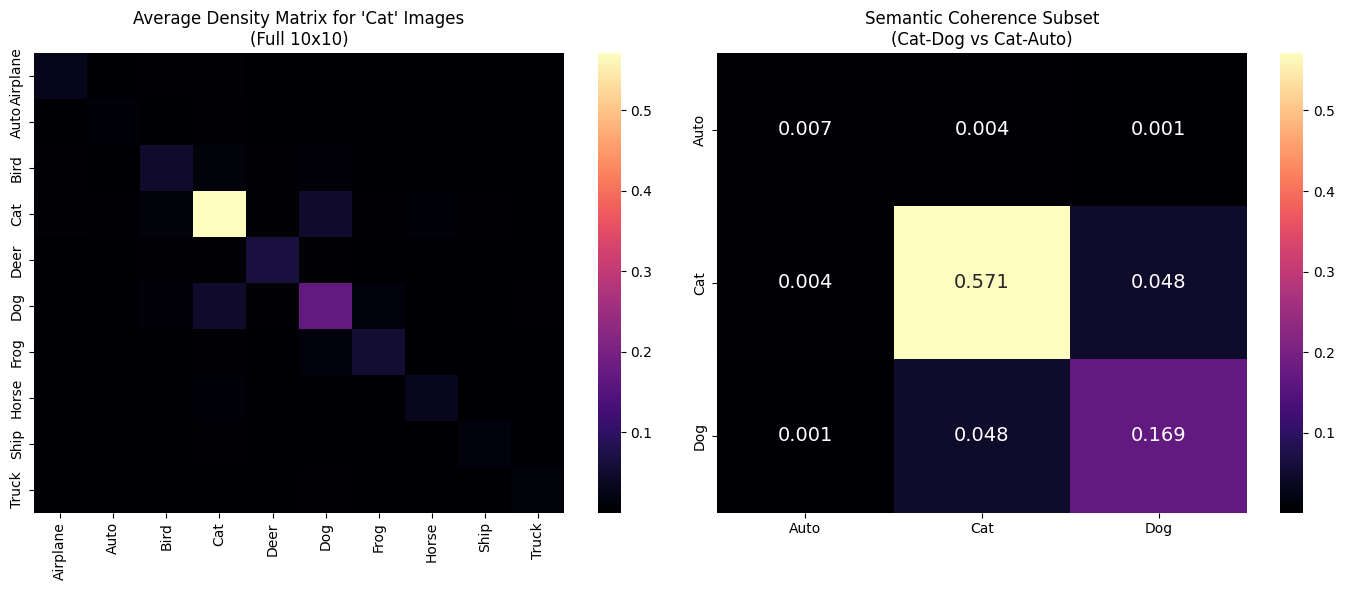

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. ARCHITECTURE DEFINITIONS
# ==========================================

class ResNetBackbone(nn.Module):
    """A simple ResNet-18 backbone adapted for CIFAR (32x32)."""
    def __init__(self):
        super().__init__()
        import torchvision.models as models
        resnet = models.resnet18(weights=None)
        # Replace the 7x7 conv with 3x3 for CIFAR's 32x32 resolution
        resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity()
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.output_dim = resnet.fc.in_features

    def forward(self, x):
        x = self.features(x)
        return torch.flatten(x, 1)

class DMH(nn.Module):
    """Standard Density Matrix Head."""
    def __init__(self, in_features, num_classes=10, rank=8):
        super().__init__()
        self.R = rank
        self.C = num_classes
        # Projection to C * R dimensions
        self.proj = nn.Linear(in_features, self.C * self.R)

    def forward(self, x, return_components=False):
        B = x.size(0)
        # z: [B, C * R] -> V: [B, R, C]
        z = self.proj(x)
        V = z.view(B, self.R, self.C)

        # L2 normalize each rank component over the class dimension
        V = F.normalize(V, p=2, dim=2)

        # Construct Density Matrix: P = (1/R) * \sum (v_r * v_r^T)
        # V is [B, R, C], V.transpose is [B, C, R]
        # P will be [B, C, C]
        P = torch.bmm(V.transpose(1, 2), V) / self.R

        if return_components:
            return P, V
        return P

class FullModel(nn.Module):
    def __init__(self, num_classes=10, rank=16):
        super().__init__()
        self.backbone = ResNetBackbone()
        self.head = DMH(self.backbone.output_dim, num_classes=num_classes, rank=rank)

    def forward(self, x, return_components=False):
        feats = self.backbone(x)
        return self.head(feats, return_components)

# ==========================================
# 2. TRAINING LOOP
# ==========================================

def train_dmh(epochs=10, rank=16, device='cuda'):
    print(f"--- Starting Training (Rank={rank}, Epochs={epochs}) ---")

    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)

    model = FullModel(num_classes=10, rank=rank).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    eps = 1e-7

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()

            P = model(inputs)
            # Born Rule: probabilities are the diagonal elements
            probs = torch.diagonal(P, dim1=-2, dim2=-1)

            # Negative Log Likelihood
            loss = F.nll_loss(torch.log(probs + eps), targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = probs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        scheduler.step()
        acc = 100. * correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {acc:.2f}%")

    return model

# ==========================================
# 3. EVALUATION & HEATMAP GENERATION
# ==========================================

def evaluate_coherence(model, device='cuda'):
    print("\n--- Evaluating Semantic Coherence ---")
    CLASS_NAMES = ['Airplane', 'Auto', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    model.eval()
    all_P = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            P = model(inputs)
            all_P.append(P.cpu().numpy())
            all_targets.append(targets.numpy())

    all_P = np.concatenate(all_P, axis=0)
    all_targets = np.concatenate(all_targets)

    # Extract 'Cat' class (Index 3)
    cat_mask = (all_targets == 3)
    mean_P_cat = np.mean(all_P[cat_mask], axis=0)

    # Compute Coherence
    cat_dog_coherence = np.abs(mean_P_cat[3, 5])
    cat_car_coherence = np.abs(mean_P_cat[3, 1])

    print("\n=== RESULTS FOR REBUTTAL ===")
    print(f"Cat-Dog Coherence (P_3,5): {cat_dog_coherence:.4f}")
    print(f"Cat-Car Coherence (P_3,1): {cat_car_coherence:.4f}")
    print("============================\n")

    # Generate Heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(np.abs(mean_P_cat), ax=axes[0], cmap="magma",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[0].set_title("Average Density Matrix for 'Cat' Images\n(Full 10x10)")

    # Zoom in
    indices = [1, 3, 5]
    subset_labels = ['Auto', 'Cat', 'Dog']
    subset_P = np.abs(mean_P_cat)[np.ix_(indices, indices)]

    sns.heatmap(subset_P, ax=axes[1], cmap="magma", annot=True, fmt=".3f",
                xticklabels=subset_labels, yticklabels=subset_labels,
                annot_kws={"size": 14})
    axes[1].set_title("Semantic Coherence Subset\n(Cat-Dog vs Cat-Auto)")

    plt.tight_layout()
    plot_path = "semantic_coherence_heatmap.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Heatmap successfully saved to: {os.path.abspath(plot_path)}")

# ==========================================
# 4. EXECUTE SCRIPT
# ==========================================
if __name__ == "__main__":
    # Ensure reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Note: Using 5 epochs for speed. For full accuracy, increase to 50+.
    trained_model = train_dmh(epochs=5, rank=16, device=device)

    # Evaluate and plot
    evaluate_coherence(trained_model, device=device)